<a href="https://colab.research.google.com/github/laksamanaap/244107020021-machine-leaning-course-2026-/blob/main/JS05/JS05_TugasLab1_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
## Import Library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier

from sklearn.feature_selection import f_classif

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [57]:
## Baca dataset
df = pd.read_csv("./voice.csv")

df.head()
df.shape
df.info()
df["label"].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

,count
label,
male,1584
female,1584


## Soal 1

In [58]:
## Pisah fitur dan target
X = df.drop("label", axis=1)
y = df["label"]

print("Jumlah fitur:", X.shape[1])
print("Jumlah data:", X.shape[0])

Jumlah fitur: 20
Jumlah data: 3168


In [59]:
## Bagi data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data training:", X_train.shape)
print("Data testing :", X_test.shape)

Data training: (2534, 20)
Data testing : (634, 20)


In [60]:
## Standarisasi fitur
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [61]:
## Buat model kNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
y_pred[:10]

accuracy = accuracy_score(y_test, y_pred)
print("Akurasi:", accuracy)
print("Akurasi: {:.2f}%".format(accuracy * 100))

print(classification_report(y_test, y_pred))

Akurasi: 0.9763406940063092
Akurasi: 97.63%
              precision    recall  f1-score   support

      female       0.99      0.97      0.98       317
        male       0.97      0.99      0.98       317

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



# Soal 2

In [62]:
## Hitung f-scores tiap fitur
scores, p_values = f_classif(
    X,
    y
)

feature_scores = pd.DataFrame({
    "Fitur": X.columns,
    "F-Score": scores,
    "P-Value": p_values
})

feature_scores = feature_scores.sort_values(
    by="F-Score",
    ascending=False
)

print("Feature scores : \n", feature_scores);

Feature scores : 
        Fitur      F-Score        P-Value
12   meanfun  7228.790362   0.000000e+00
5        IQR  1965.750000   0.000000e+00
3        Q25  1121.569224  9.140832e-211
8     sp.ent  1003.308717  1.614016e-191
1         sd   945.461376  6.654756e-182
9        sfm   463.923194   3.877715e-96
11  centroid   406.752820   3.368951e-85
0   meanfreq   406.752820   3.368951e-85
2     median   277.588158   8.259210e-60
17    maxdom   126.024161   1.050986e-28
16    mindom   125.110999   1.636130e-28
18   dfrange   121.457858   9.626061e-28
15   meandom   119.959108   1.992966e-27
10      mode    96.257909   2.097044e-22
14    maxfun    90.228036   4.044625e-21
13    minfun    60.282137   1.101400e-14
7       kurt    24.255365   8.869557e-07
4        Q75    14.236082   1.642021e-04
6       skew     4.252980   3.926293e-02
19   modindx     3.006445   8.303136e-02


In [63]:
## Lihat 9 fitur terbaik
best_features = feature_scores.head(9)["Fitur"].tolist()

print(best_features)

['meanfun', 'IQR', 'Q25', 'sp.ent', 'sd', 'sfm', 'centroid', 'meanfreq', 'median']


In [64]:
## Siapkan cross validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

feature_results = []

for n in range(1, 21):

    selected_features = feature_scores.head(n)["Fitur"].tolist()

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ])

    scores = cross_val_score(
        model,
        X[selected_features],
        y,
        cv=cv,
        scoring="accuracy"
    )

    feature_results.append({
        "Jumlah Fitur": n,
        "Akurasi": scores.mean()
    })

feature_results = pd.DataFrame(feature_results)
print(feature_results)


feature_results.loc[
    feature_results["Akurasi"].idxmax()
]

    Jumlah Fitur   Akurasi
0              1  0.947284
1              2  0.968751
2              3  0.973485
3              4  0.974746
4              5  0.978532
5              6  0.981376
6              7  0.981061
7              8  0.980112
8              9  0.982324
9             10  0.979167
10            11  0.976958
11            12  0.976958
12            13  0.976010
13            14  0.976325
14            15  0.975379
15            16  0.977589
16            17  0.977588
17            18  0.977272
18            19  0.976641
19            20  0.975062


,8
Jumlah Fitur,9.000000
Akurasi,0.982324


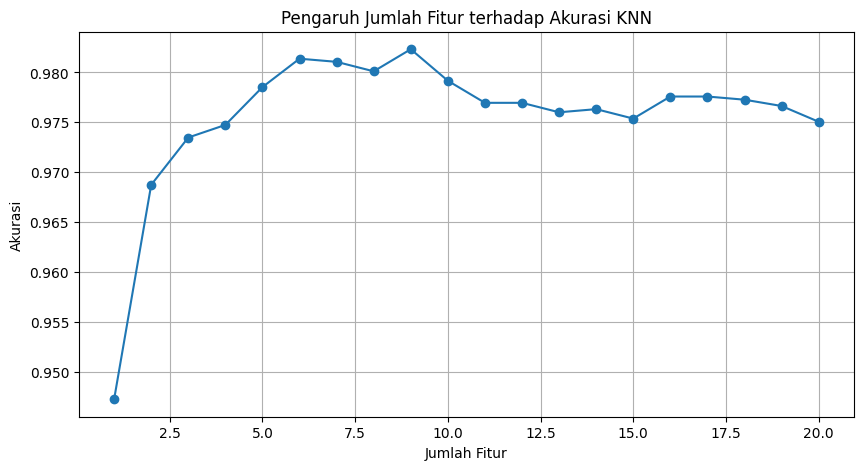

In [65]:
## Analisis Fitur
plt.figure(figsize=(10, 5))

plt.plot(
    feature_results["Jumlah Fitur"],
    feature_results["Akurasi"],
    marker="o"
)

plt.xlabel("Jumlah Fitur")
plt.ylabel("Akurasi")
plt.title("Pengaruh Jumlah Fitur terhadap Akurasi KNN")

plt.grid(True)

plt.show()

# Soal 3

In [66]:

## Ambil 9 fitur terbaik
best_features = feature_scores.head(9)["Fitur"].tolist()

X_best = X[best_features]

print("Fitur yang digunakan:")
print(best_features)

Fitur yang digunakan:
['meanfun', 'IQR', 'Q25', 'sp.ent', 'sd', 'sfm', 'centroid', 'meanfreq', 'median']


In [67]:
## Bagi nilai K
k_results = []

for k in range(1, 32, 2):

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_val_score(
        model,
        X_best,
        y,
        cv=cv,
        scoring="accuracy"
    )

    k_results.append({
        "k": k,
        "Akurasi": scores.mean()
    })

k_results = pd.DataFrame(k_results)

print(k_results)

k_results.loc[
    k_results["Akurasi"].idxmax()
]

     k   Akurasi
0    1  0.977272
1    3  0.979166
2    5  0.982324
3    7  0.981062
4    9  0.978852
5   11  0.978852
6   13  0.978536
7   15  0.975380
8   17  0.973171
9   19  0.972540
10  21  0.972540
11  23  0.972225
12  25  0.971908
13  27  0.970961
14  29  0.970330
15  31  0.968752


,2
k,5.000000
Akurasi,0.982324


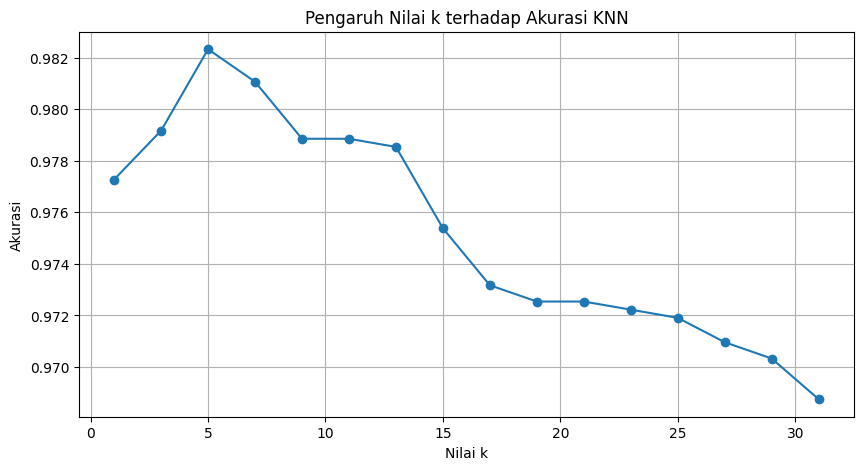

In [68]:
## Analisa nilai K
plt.figure(figsize=(10, 5))

plt.plot(
    k_results["k"],
    k_results["Akurasi"],
    marker="o"
)

plt.xlabel("Nilai k")
plt.ylabel("Akurasi")
plt.title("Pengaruh Nilai k terhadap Akurasi KNN")

plt.grid(True)

plt.show()

In [69]:
X_final = X[best_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Training model final
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

final_model.fit(X_train, y_train)

## Evaluasi
y_pred = final_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Akurasi Model Final: {:.2f}%".format(accuracy * 100))

Akurasi Model Final: 98.58%


Berdasarkan percobaan klasifikasi suara menggunakan algoritma KNN pada dataset voice.csv, model dapat digunakan untuk mengklasifikasikan suara menjadi dua kelas, yaitu male dan female. Dataset terdiri dari 3.168 data dengan 20 fitur numerik. Sebelum proses klasifikasi, dilakukan standardisasi fitur karena KNN menggunakan perhitungan jarak.

Dari percobaan pemilihan fitur, penggunaan seluruh 20 fitur tidak menghasilkan performa terbaik. Setelah dilakukan pengujian terhadap jumlah fitur, diperoleh 9 fitur yang memberikan hasil paling optimal, yaitu meanfun, IQR, Q25, sp.ent, sd, sfm, centroid, meanfreq, dan median. Dengan kombinasi tersebut, rata-rata akurasi 5-fold cross-validation mencapai sekitar 98,23%.

Selanjutnya dilakukan pengujian beberapa nilai k untuk menentukan jumlah tetangga yang paling sesuai. Dari nilai k yang diuji, yaitu 1 sampai 31 dengan interval 2, nilai k=5 menghasilkan akurasi rata-rata cross-validation tertinggi, yaitu sekitar 98,23%. Oleh karena itu, model akhir menggunakan 9 fitur tersebut dengan k=5. Pada pengujian menggunakan data testing sebesar 20%, model memperoleh akurasi sekitar 98,58%, sehingga model KNN mampu melakukan klasifikasi jenis suara male dan female dengan performa yang tinggi pada dataset ini.